Mounted at /content/drive
Loading dataset...
Encoding and imputing data...
Training LightGBM... (Silent mode active, this will be fast!)

===== LIGHTGBM PERFORMANCE =====
RMSE: 0.2100
MAE : 0.1543
R2  : 0.9085


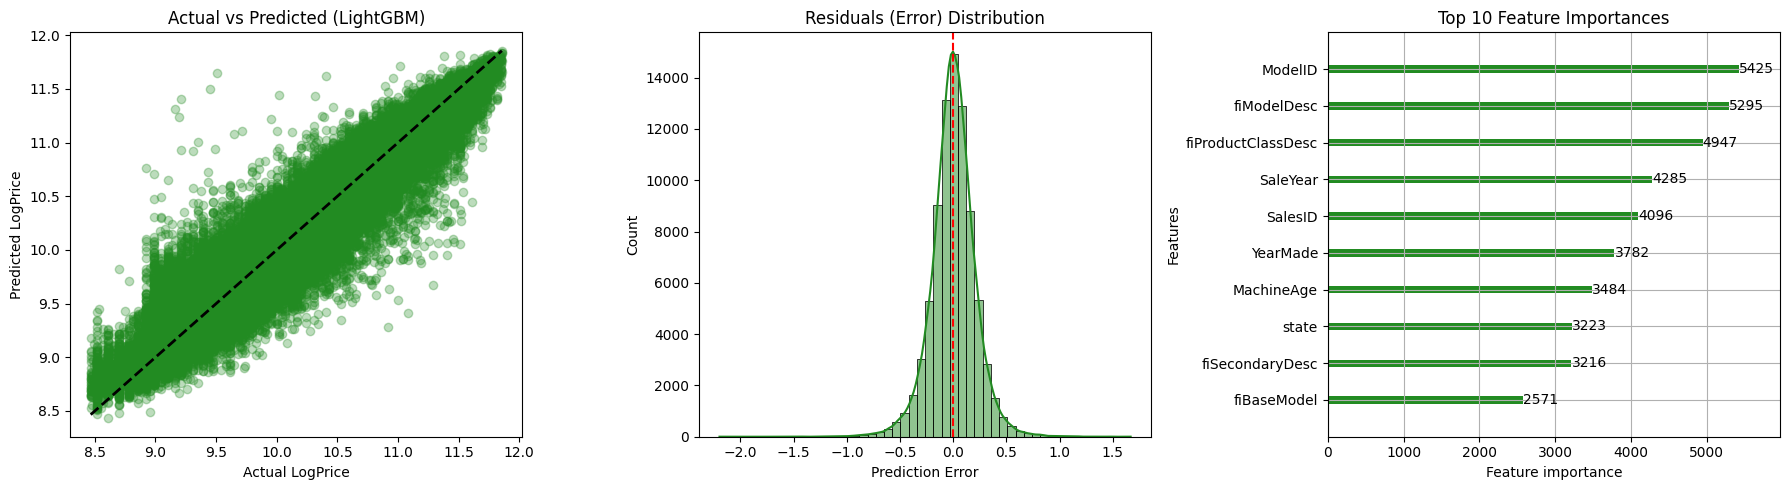


Exporting model for Streamlit Dashboard...
Success! 'lgbm_bulldozer_model.pkl' saved to Colab files. Please download it.


In [1]:
"""
Group 2
Obil Nathaniel - 271048001
Muhammad Abdullah - 281134982
"""
# ==========================================
# EXPERIMENT 5: LIGHTGBM (HIGH-SPEED BOOSTING)
# ==========================================
"""
OVERVIEW: This notebook implements LightGBM (Light Gradient Boosting Machine).
Because Deep Neural Networks can take hours to train on CPU and struggle with
tabular data, LightGBM is used here as our final model to achieve maximum efficiency.

STEPS:
1. TARGET SCALING: Log transform (np.log) to normalize the price distribution.
2. HISTOGRAM BINNING: LightGBM automatically groups continuous features into
   discrete bins, which speeds up training significantly.
3. LEAK-PROOF IMPUTATION: Filled missing values based ONLY on training medians,
   plus added binary missing flags.
4. LEAF-WISE GROWTH: Unlike XGBoost which grows level-by-level, LightGBM grows
   trees leaf-by-leaf, targeting the splits with the highest error reduction first.
5. DEPLOYMENT EXPORT: Saves the trained model as a .pkl file for live dashboard use.

GOAL: To match the high R-squared of XGBoost (>0.91) while reducing training
      time from hours to just a few minutes.
"""

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import joblib # Added for saving the model!

# ----------------------------
# 1. Mount & Load
# ----------------------------
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/ML/TrainAndValid.csv'

print("Loading dataset...")
df = pd.read_csv(file_path, low_memory=False)

# ----------------------------
# 2. Advanced Feature Engineering
# ----------------------------
df['LogPrice'] = np.log(df['SalePrice'])
df['saledate'] = pd.to_datetime(df['saledate'])
df['SaleYear']  = df['saledate'].dt.year
df['SaleMonth'] = df['saledate'].dt.month
df['SaleDay']   = df['saledate'].dt.day
df['DayOfWeek'] = df['saledate'].dt.dayofweek
df.drop('saledate', axis=1, inplace=True)

df['YearMade']   = df['YearMade'].replace(1000, np.nan)
df['MachineAge'] = df['SaleYear'] - df['YearMade']

df['MonthSin'] = np.sin(2 * np.pi * df['SaleMonth'] / 12)
df['MonthCos'] = np.cos(2 * np.pi * df['SaleMonth'] / 12)
df['YearsSinceMedian'] = df['SaleYear'] - df['SaleYear'].median()

# ----------------------------
# 3. Leak-Proof Preprocessing
# ----------------------------
print("Encoding and imputing data...")

# LightGBM prefers integers for categorical data
for label, content in df.items():
    if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
        df[label] = content.astype("category").cat.codes + 1

# Train-Test Split
X = df.drop(['SalePrice', 'LogPrice'], axis=1)
y = df['LogPrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute with Training Median + Missing Flags
for label, content in X_train.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            X_train[label + "_is_missing"] = pd.isnull(content).astype(int)
            X_test[label + "_is_missing"]  = pd.isnull(X_test[label]).astype(int)

            mid = content.median()
            X_train[label] = X_train[label].fillna(mid)
            X_test[label]  = X_test[label].fillna(mid)

# ----------------------------
# 4. High-Speed Modeling
# ----------------------------
print("Training LightGBM... (Silent mode active, this will be fast!)")

# verbose=-1 completely silences the LightGBM logging output
model_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# early_stopping verbose=False silences the round-by-round output
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=callbacks
)

# ----------------------------
# 5. Evaluation
# ----------------------------
y_pred = model_lgb.predict(X_test)

print("\n===== LIGHTGBM PERFORMANCE =====")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")

# ----------------------------
# 6. Visualizations
# ----------------------------
plt.figure(figsize=(18, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.3, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual LogPrice")
plt.ylabel("Predicted LogPrice")
plt.title("Actual vs Predicted (LightGBM)")

# Plot 2: Residuals Distribution
plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, bins=50, kde=True, color='forestgreen')
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals (Error) Distribution")
plt.xlabel("Prediction Error")

# Plot 3: Feature Importance
plt.subplot(1, 3, 3)
lgb.plot_importance(model_lgb, max_num_features=10, ax=plt.gca(), color='forestgreen')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# ----------------------------
# 7. Model Export for Deployment
# ----------------------------
print("\nExporting model for Streamlit Dashboard...")
joblib.dump(model_lgb, 'lgbm_bulldozer_model.pkl')
print("Success! 'lgbm_bulldozer_model.pkl' saved to Colab files. Please download it.")

In [4]:
feat_imp = pd.Series(model_lgb.feature_importances_, index=X_train.columns)
print(feat_imp.nlargest(10))

ModelID               5425
fiModelDesc           5295
fiProductClassDesc    4947
SaleYear              4285
SalesID               4096
YearMade              3782
MachineAge            3484
state                 3223
fiSecondaryDesc       3216
fiBaseModel           2571
dtype: int32
